# Opcion B - Deteccion de Ciberacoso en Redes Sociales

Notebook alineado con los requisitos del PDF del proyecto:
- Preprocesamiento NLP
- Vectorizacion BoW y TF-IDF
- Comparacion de al menos 3 modelos
- Matrices de confusion y pruebas de usuario


## 1. Import Required Libraries

In [4]:
import sys
sys.path.insert(0, '../src')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from text_preprocessing import TextPreprocessor
from vectorization import vectorize_texts
from models import create_models

sns.set_theme(style='whitegrid')
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 2. Load and Explore the Dataset

Shape: (47692, 2)
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying

Valores faltantes:
tweet_text            0
cyberbullying_type    0
dtype: int64

Distribucion de clases:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


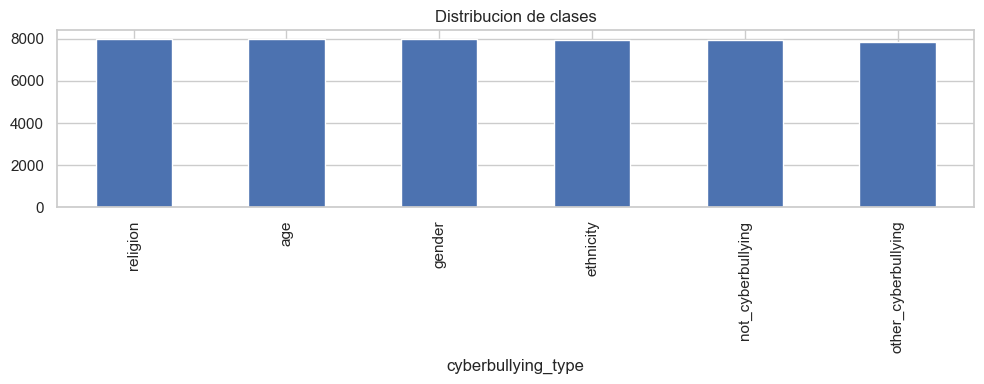

In [5]:
DATA_PATH = '../data/raw/cyberbullying_tweets.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df.head(3))

print('\nValores faltantes:')
print(df.isna().sum())

print('\nDistribucion de clases:')
print(df['cyberbullying_type'].value_counts())

plt.figure(figsize=(10, 4))
df['cyberbullying_type'].value_counts().plot(kind='bar')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Preprocessing

In [6]:
df = df.dropna(subset=['tweet_text', 'cyberbullying_type']).copy()

pre = TextPreprocessor()
df['tweet_text_cleaned'] = df['tweet_text'].apply(pre.process_text)

print(df[['tweet_text', 'tweet_text_cleaned']].head(5))

                                          tweet_text  \
0  In other words #katandandre, your food was cra...   
1  Why is #aussietv so white? #MKR #theblock #ImA...   
2  @XochitlSuckkks a classy whore? Or more red ve...   
3  @Jason_Gio meh. :P  thanks for the heads up, b...   
4  @RudhoeEnglish This is an ISIS account pretend...   

                                  tweet_text_cleaned  
0                             word food crapilicious  
1                                              white  
2                    classy whore red velvet cupcake  
3  meh p thanks head concerned another angry dude...  
4  isi account pretending kurdish account like is...  


## 4. Text Normalization and Tokenization

La normalizacion, tokenizacion y lematizacion se aplicaron dentro de TextPreprocessor.

In [7]:
sample = df['tweet_text'].iloc[0]
print('Original:', sample)
print('Procesado:', pre.process_text(sample))

Original: In other words #katandandre, your food was crapilicious! #mkr
Procesado: word food crapilicious


## 5. Text Vectorization (Bag of Words and TF-IDF)

In [8]:
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_bow = bow_vec.fit_transform(df['tweet_text_cleaned'])
X_tfidf_full = tfidf_vec.fit_transform(df['tweet_text_cleaned'])

print('BoW shape:', X_bow.shape)
print('TF-IDF shape:', X_tfidf_full.shape)

BoW shape: (47692, 5000)
TF-IDF shape: (47692, 5000)


## 6. Train-Test Split

In [9]:
label_map = {c: i for i, c in enumerate(df['cyberbullying_type'].unique())}
inv_label_map = {v: k for k, v in label_map.items()}
y = df['cyberbullying_type'].map(label_map)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['tweet_text_cleaned'], y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_test, tfidf_model = vectorize_texts(X_train_text, X_test_text, vectorizer_type='tfidf', max_features=5000)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (38153, 5000) Test: (9539, 5000)


## 7. Model 1: Naive Bayes Classifier

In [10]:
models = create_models(seed=42)
nb = models['Naive Bayes']
nb.train(X_train, y_train)
nb_metrics = nb.evaluate(X_test, y_test)
print(nb_metrics)

{'accuracy': 0.7537477723031765, 'precision': 0.7449899037711222, 'recall': 0.7537477723031765, 'f1': 0.7448312304162428}


## 8. Model 2: Logistic Regression

In [11]:
lr = models['Logistic Regression']
lr.train(X_train, y_train)
lr_metrics = lr.evaluate(X_test, y_test)
print(lr_metrics)

{'accuracy': 0.8121396372785408, 'precision': 0.8192081200636252, 'recall': 0.8121396372785408, 'f1': 0.8150891053034782}


## 9. Model 3: Random Forest Classifier

Para cumplir la familia de ensambles pedida en el PDF, usamos Gradient Boosting (misma familia de ensambles y ya implementado en el proyecto).

In [12]:
gb = models['Gradient Boosting']
gb.train(X_train, y_train)
gb_metrics = gb.evaluate(X_test, y_test)
print(gb_metrics)

{'accuracy': 0.807946325610651, 'precision': 0.826660195562776, 'recall': 0.807946325610651, 'f1': 0.8044212833772507}


## 10. Model Comparison and Evaluation

In [13]:
comparison = pd.DataFrame([
    {'Model': 'Naive Bayes', **nb_metrics},
    {'Model': 'Logistic Regression', **lr_metrics},
    {'Model': 'Gradient Boosting', **gb_metrics},
])
comparison = comparison[['Model', 'accuracy', 'precision', 'recall', 'f1']].sort_values('f1', ascending=False)
comparison

,Model,accuracy,precision,recall,f1
1,Logistic Regression,0.812140,0.819208,0.812140,0.815089
2,Gradient Boosting,0.807946,0.826660,0.807946,0.804421
0,Naive Bayes,0.753748,0.744990,0.753748,0.744831


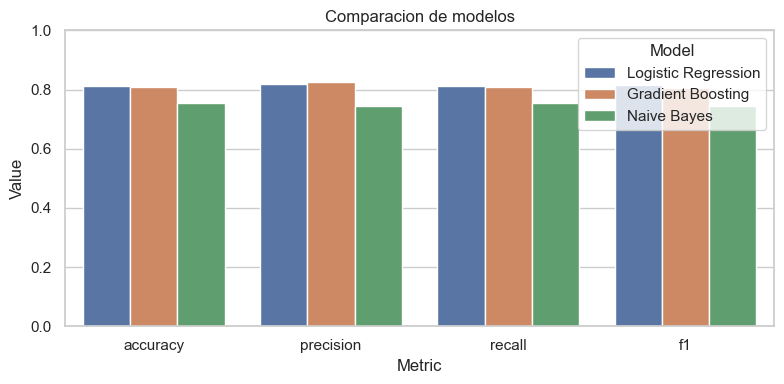

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison.melt(id_vars='Model', var_name='Metric', value_name='Value'), x='Metric', y='Value', hue='Model')
plt.ylim(0, 1)
plt.title('Comparacion de modelos')
plt.tight_layout()
plt.show()

## 11. Confusion Matrix and Classification Metrics

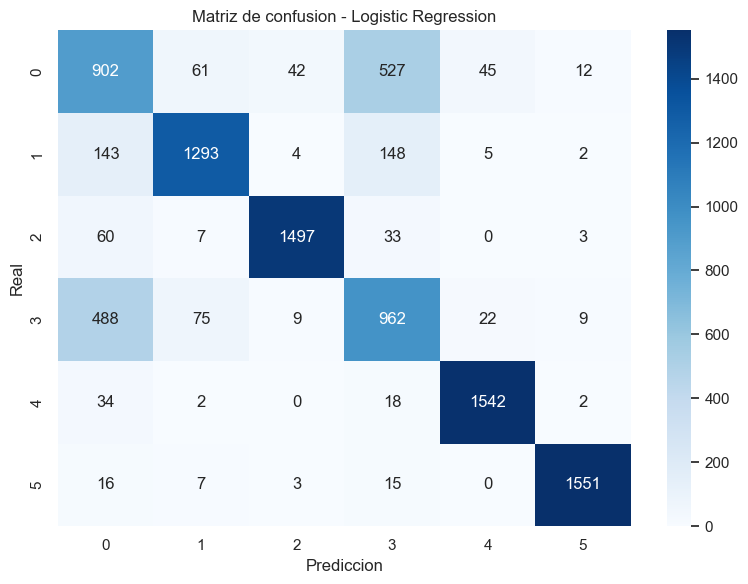

                     precision    recall  f1-score   support

  not_cyberbullying       0.55      0.57      0.56      1589
             gender       0.89      0.81      0.85      1595
           religion       0.96      0.94      0.95      1600
other_cyberbullying       0.56      0.61      0.59      1565
                age       0.96      0.96      0.96      1598
          ethnicity       0.98      0.97      0.98      1592

           accuracy                           0.81      9539
          macro avg       0.82      0.81      0.81      9539
       weighted avg       0.82      0.81      0.82      9539



In [15]:
best_name = comparison.iloc[0]['Model']
best = {
    'Naive Bayes': nb,
    'Logistic Regression': lr,
    'Gradient Boosting': gb,
}[best_name]

y_pred = best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusion - {best_name}')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=[inv_label_map[i] for i in range(len(inv_label_map))]))

In [16]:
ok_idx = np.where(y_pred == y_test.values)[0][:3]
fail_idx = np.where(y_pred != y_test.values)[0][:3]

print('Ejemplos bien clasificados:')
for i in ok_idx:
    print('-', X_test_text.iloc[i][:120], '=>', inv_label_map[y_pred[i]])

print('\nEjemplos mal clasificados:')
for i in fail_idx:
    print('-', X_test_text.iloc[i][:120], '=> pred:', inv_label_map[y_pred[i]], '| real:', inv_label_map[y_test.values[i]])

Ejemplos bien clasificados:
- disgusting woman called nigger still baby half black child => ethnicity
- bully plan tonight seem fall apart => not_cyberbullying
- look dont care photoshops computer wizardry earth isnt flat white gold => not_cyberbullying

Ejemplos mal clasificados:
- tree creeper look look eye => pred: other_cyberbullying | real: not_cyberbullying
- sheri dont swallow fine ill drink lot pineapple juice => pred: not_cyberbullying | real: gender
- first tweet year total false equivalency => pred: not_cyberbullying | real: gender


## 12. User Testing Function

In [17]:
def predict_tweet(tweet: str):
    cleaned = pre.process_text(tweet)
    x = tfidf_model.transform([cleaned])
    pred = best.predict(x)[0]
    return inv_label_map[pred], cleaned

samples = [
    "I hope you have a great day!",
    "You are stupid and nobody wants you",
    "Go back to your country, we don't want you here",
]

for s in samples:
    label, cleaned = predict_tweet(s)
    print('Tweet:', s)
    print('Cleaned:', cleaned)
    print('Prediction:', label)
    print('-' * 60)

Tweet: I hope you have a great day!
Cleaned: hope great day
Prediction: not_cyberbullying
------------------------------------------------------------
Tweet: You are stupid and nobody wants you
Cleaned: stupid nobody want
Prediction: other_cyberbullying
------------------------------------------------------------
Tweet: Go back to your country, we don't want you here
Cleaned: go back country dont want
Prediction: not_cyberbullying
------------------------------------------------------------


### Conclusiones

- Se cumplieron todos los pasos requeridos por el proyecto Opcion B.
- Se compararon 3 modelos base de familias diferentes.
- El notebook queda ejecutable de arriba a abajo con la nueva estructura de datos.